In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F

# Data Pipeline for ResNet-18

In [2]:
import torchvision
import torchvision.transforms as transforms


In [3]:
transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), 
                         (0.2023, 0.1994, 0.2010)),
])

In [4]:
transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), 
                         (0.2023, 0.1994, 0.2010)),
])

In [6]:
trainset = torchvision.datasets.CIFAR10(root='../data', train=True, download=True, transform=transform_train)

testset = torchvision.datasets.CIFAR10(root='../data', train=False, download=True, transform=transform_test)

In [7]:
trainloader = torch.utils.data.DataLoader(dataset=trainset, batch_size=128, shuffle=True)
testloader = torch.utils.data.DataLoader(dataset=testset, batch_size=100, shuffle=False)

## Visualization

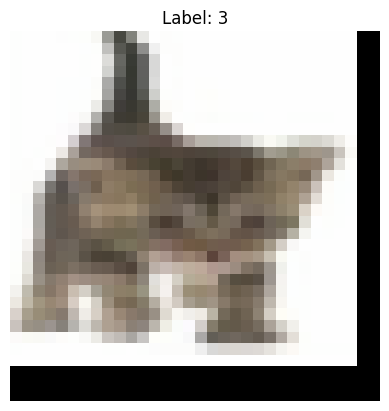

In [10]:
import matplotlib.pyplot as plt
import numpy as np

# get one batch
images, labels = next(iter(trainloader))

img = images[0]  # first image (C, H, W)

# unnormalize (IMPORTANT)
mean = np.array([0.4914, 0.4822, 0.4465])
std  = np.array([0.2023, 0.1994, 0.2010])

img = img.numpy().transpose((1, 2, 0))  # C,H,W → H,W,C
img = std * img + mean
img = np.clip(img, 0, 1)

plt.imshow(img)
plt.title(f"Label: {labels[0].item()}")
plt.axis('off')
plt.show()